In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import uproot




In [48]:
# Load ROOT file

def load_root(file, tree_name=None):

    with uproot.open(file) as f:

        # Auto-detect tree if not provided
        if tree_name is None:
            keys = f.keys()
            print("Available keys:", keys)

            # pick first TTree
            for k in keys:
                if "tree" in k.lower():
                    tree_name = k.split(";")[0]
                    break

            print("Using tree:", tree_name)

        tree = f[tree_name]

        data = {}
        for branch in tree.keys():
            data[branch] = tree[branch].array(library="np")

    return data

def hist(data, title, bins=50):
    data = data[np.isfinite(data)]
    plt.figure()
    plt.hist(data, bins=bins, alpha=0.7)
    plt.title(title)
    plt.xlabel(title)
    plt.ylabel("Events")
    plt.show()

def hist2d(x, y, xlabel, ylabel):
    mask = np.isfinite(x) & np.isfinite(y)
    plt.figure()
    plt.hist2d(x[mask], y[mask], bins=60)
    plt.colorbar(label="Events")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


In [49]:
def validate(file):

    d = load_root("nue20gev.root")

    # Required branches
    E = d["E"]
    finalE = d["finalE"]
    costh = d["costh"]
    phi = d["phi"]

    # --------------------------------
    # 1. Lepton kinematics
    # --------------------------------
    hist(finalE, "Final lepton energy (GeV)")
    hist(costh, "cos(theta)")
    hist(phi, "phi (should be flat)")

    hist2d(costh, finalE, "cos(theta)", "Final E")

    # --------------------------------
    # 2. Energy conservation (CRITICAL)
    # --------------------------------
    closure = (finalE + d["totalEdep"]) / E
    hist(closure, "Energy closure (should peak at 1)")

    # --------------------------------
    # 3. Multiplicity
    # --------------------------------
    hist(d["nSecondaries"], "Total secondaries")
    hist(d["nPionPlus"], "π+ multiplicity")
    hist(d["nPionMinus"], "π- multiplicity")
    hist(d["nGamma"], "Gamma multiplicity")

    # --------------------------------
    # 4. EM processes
    # --------------------------------
    hist(d["nIonisation"], "Ionisation")
    hist(d["nBremsstrahlung"], "Bremsstrahlung")
    hist(d["nCompton"], "Compton")

    # --------------------------------
    # 5. Topology
    # --------------------------------
    shower_len = d["secLastZ"] - d["secFirstZ"]
    hist(shower_len, "Shower length (Z)")

    hist(d["nBackward"], "Backward tracks")

    print("Validation plots done")

Available keys: ['tree;1']
Using tree: tree


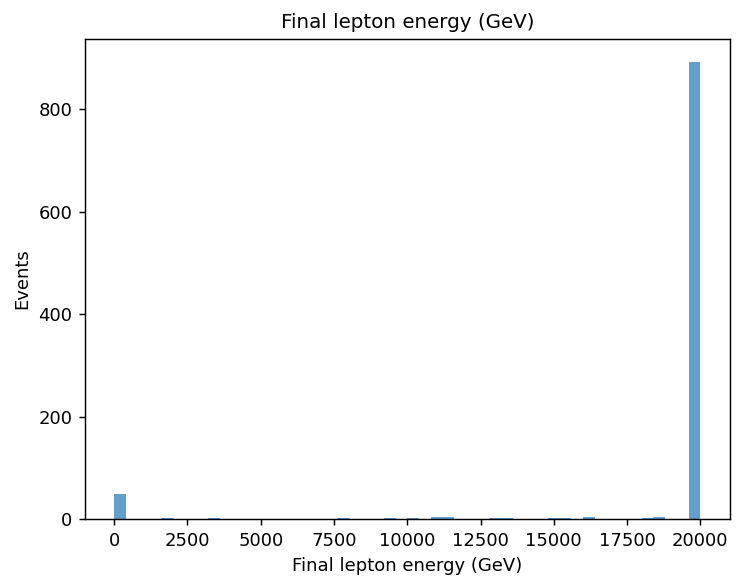

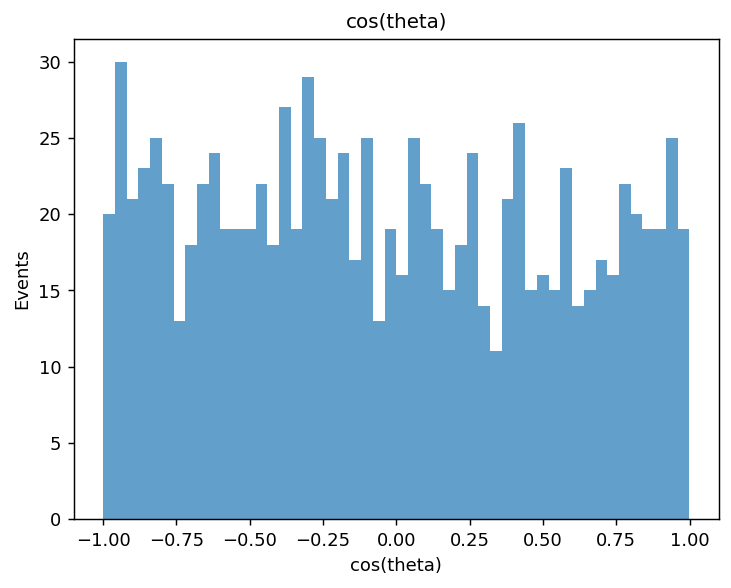

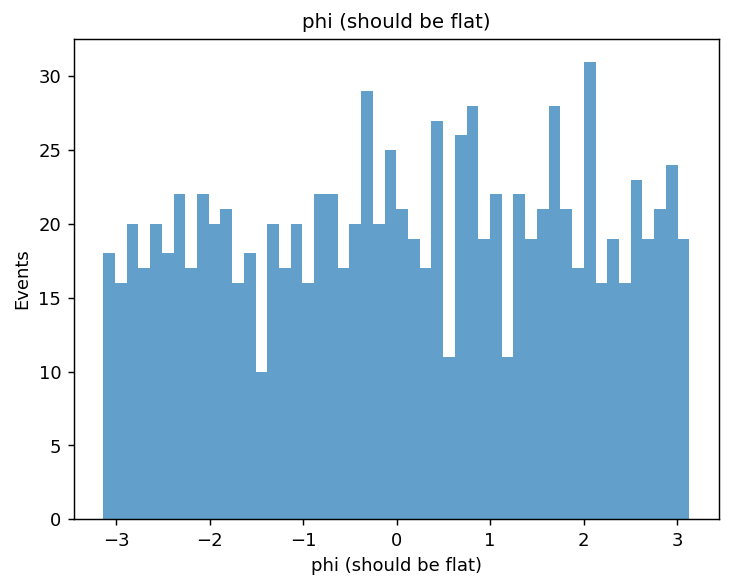

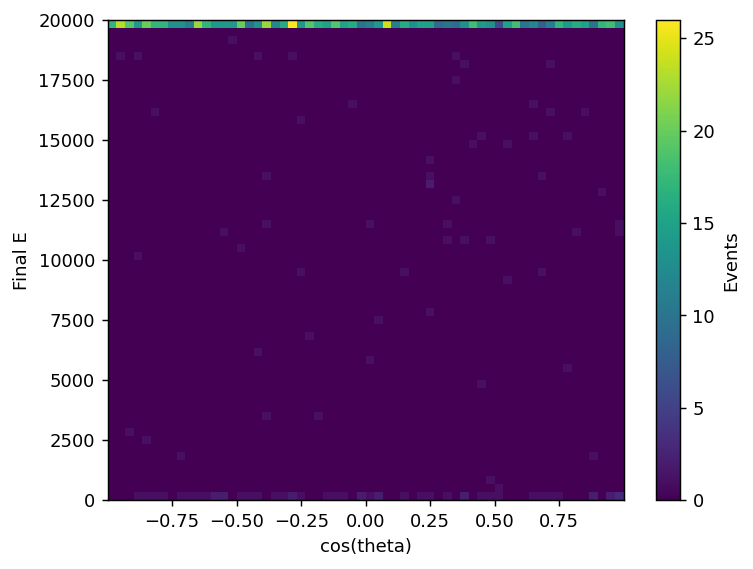

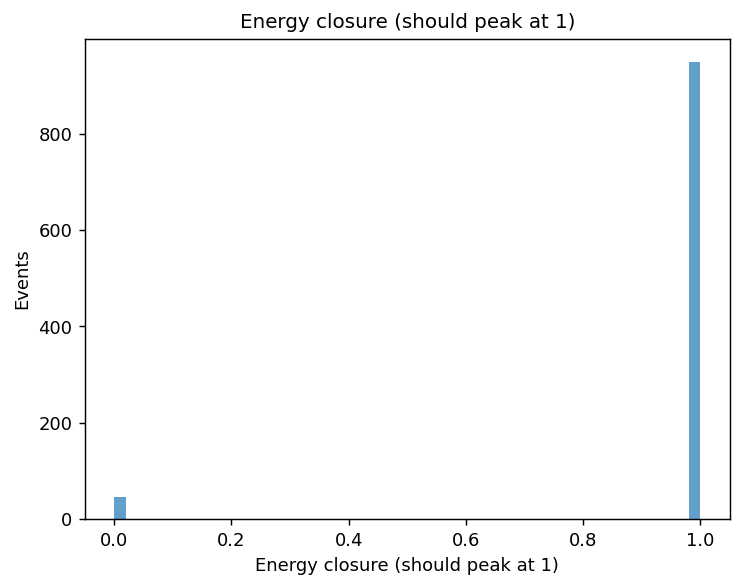

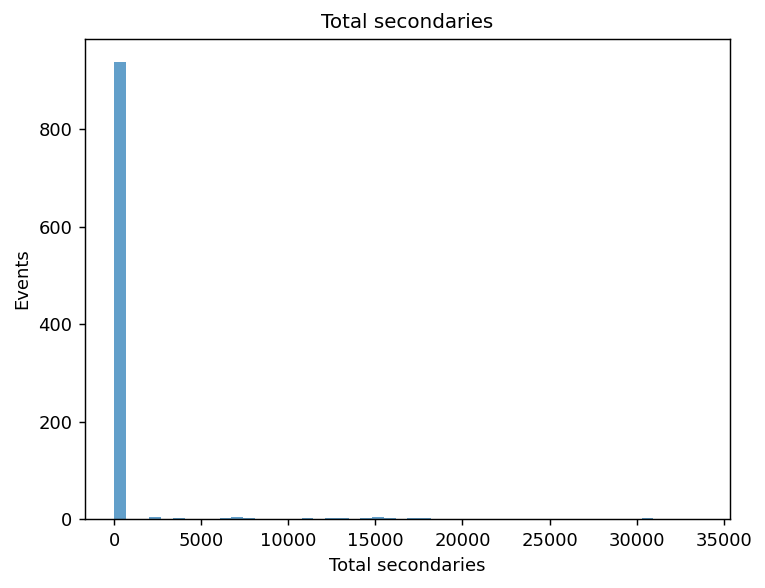

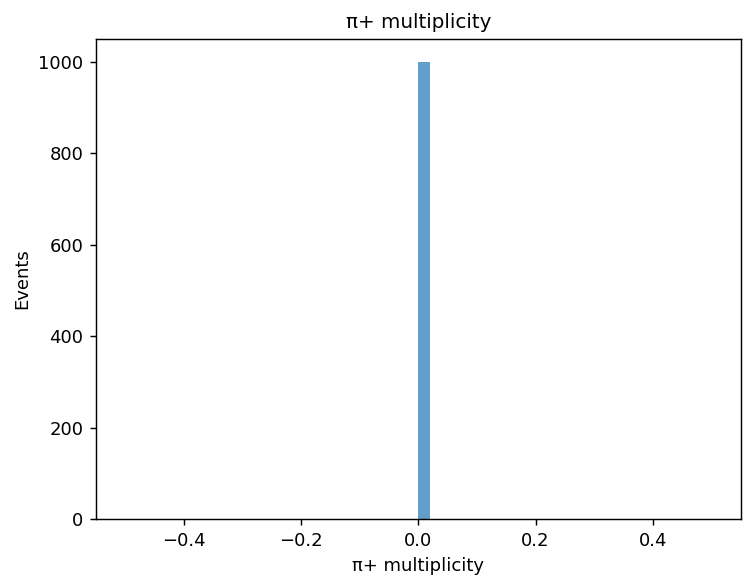

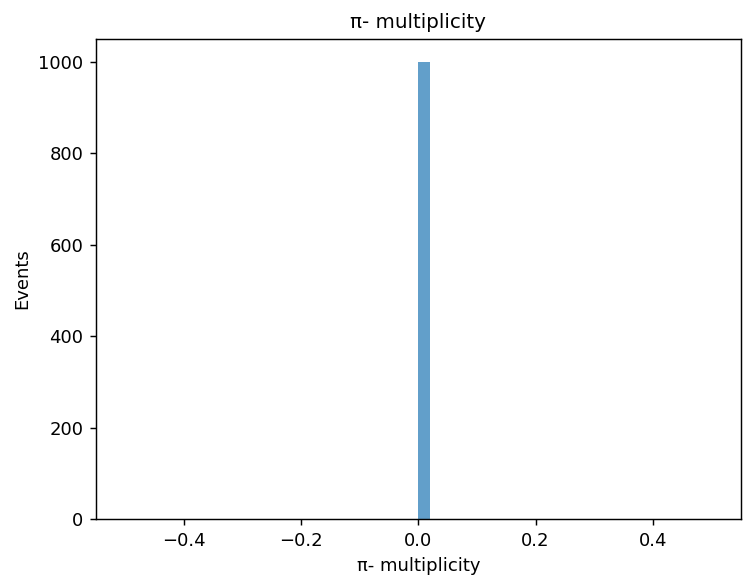

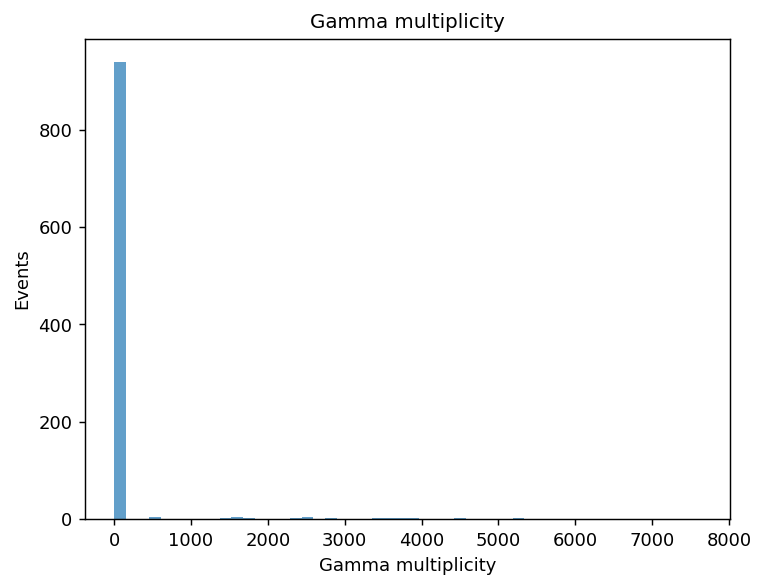

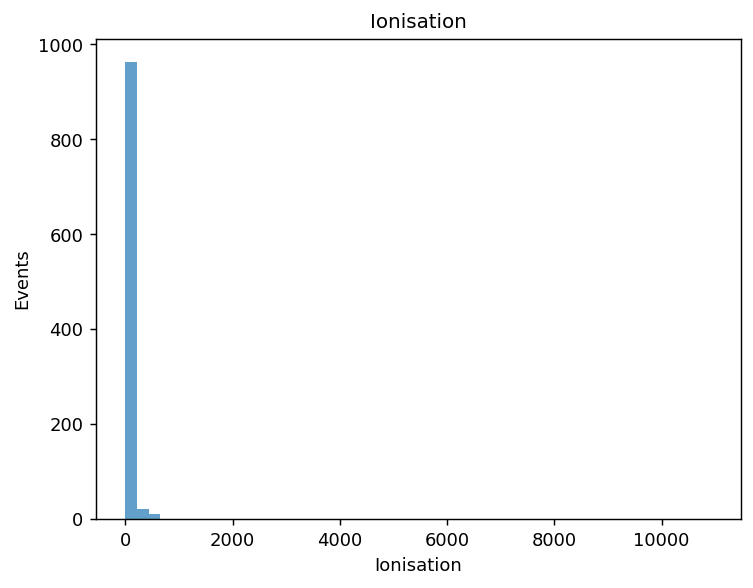

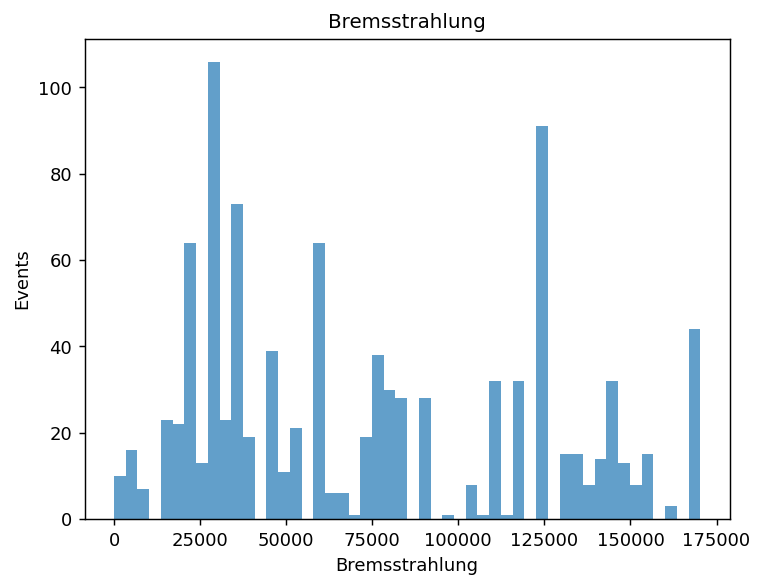

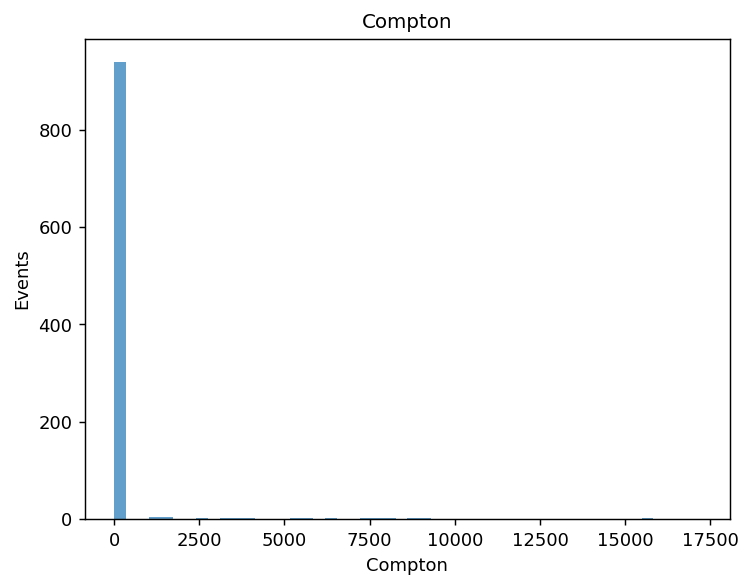

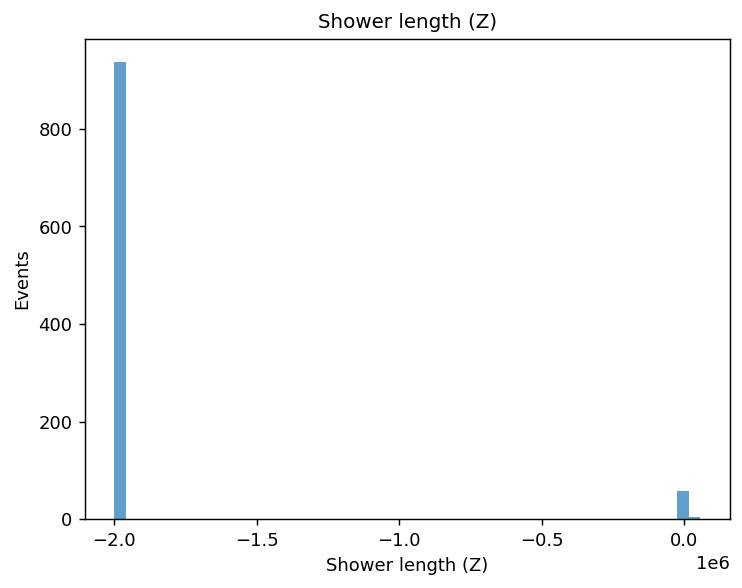

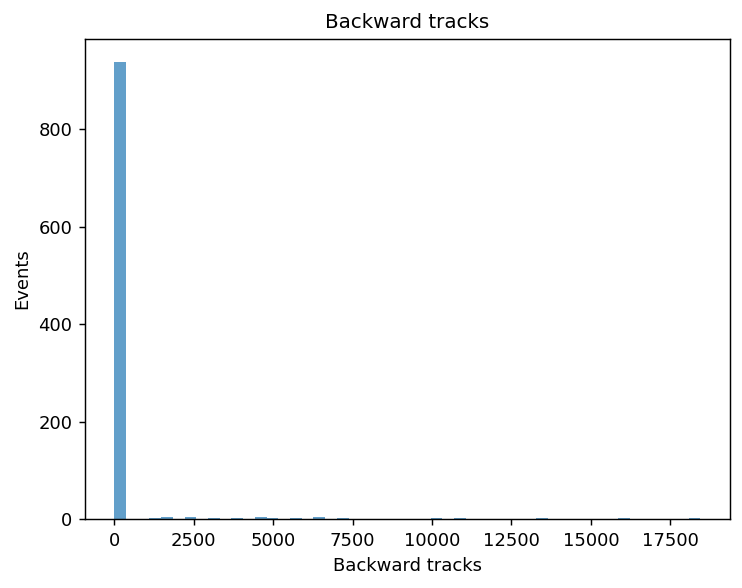

Validation plots done


In [50]:
validate("nue20gev.root")